In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

Iris dataset loaded


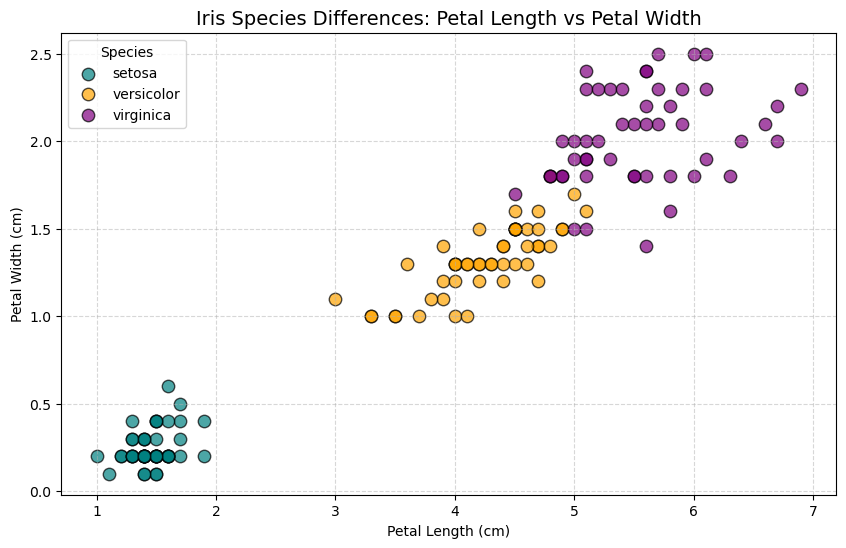

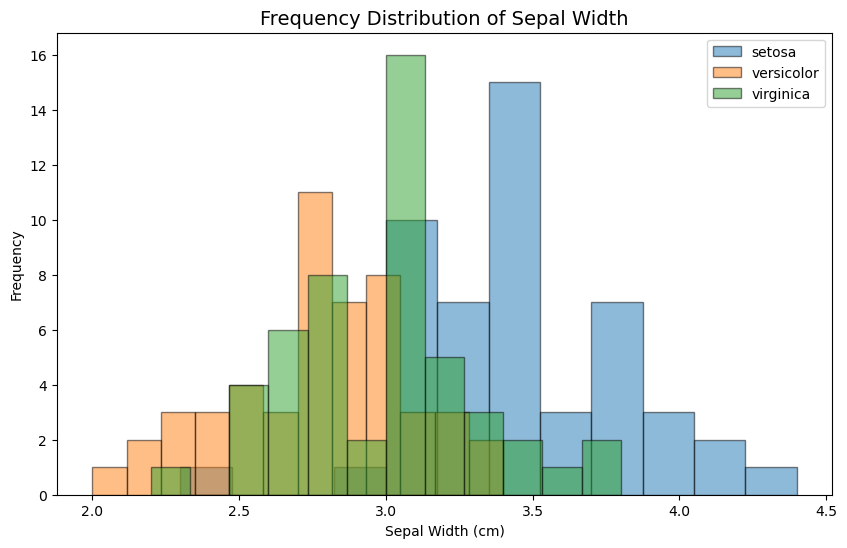

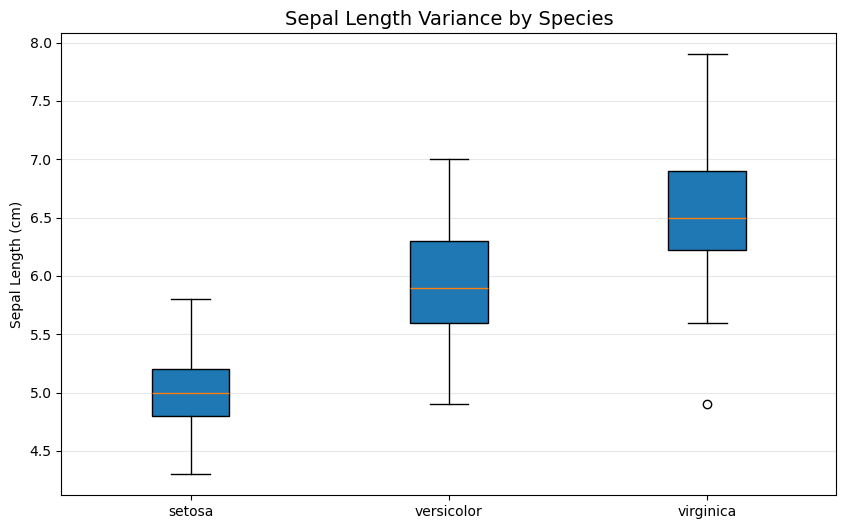

Error: loan_data.csv not found. Using Mock data mirroring Kaggle structure.


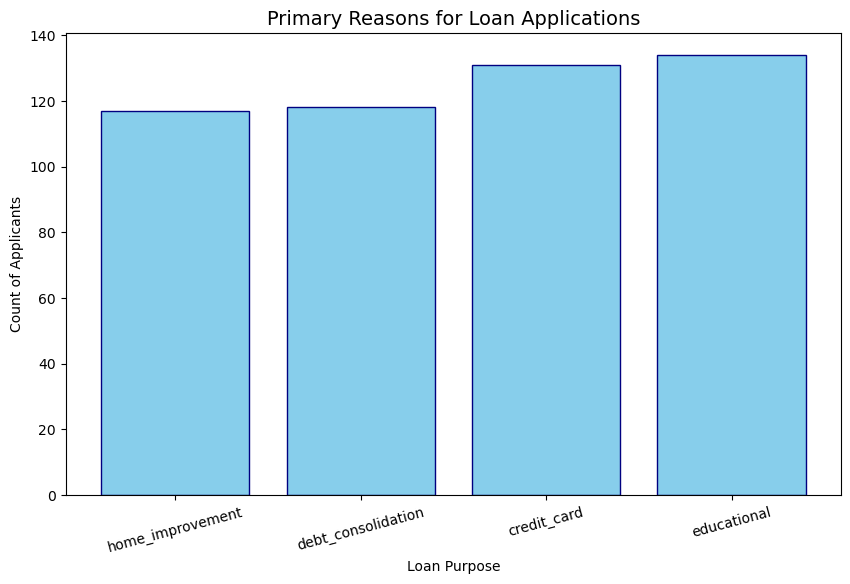

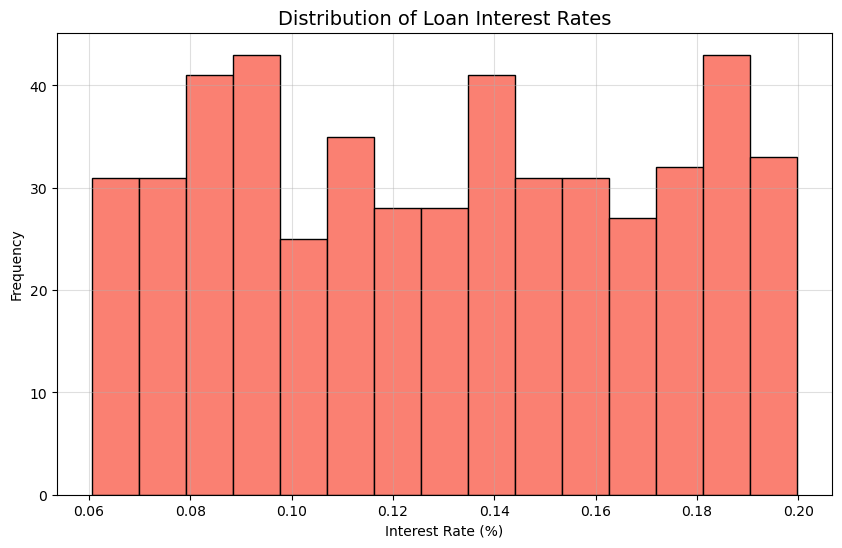

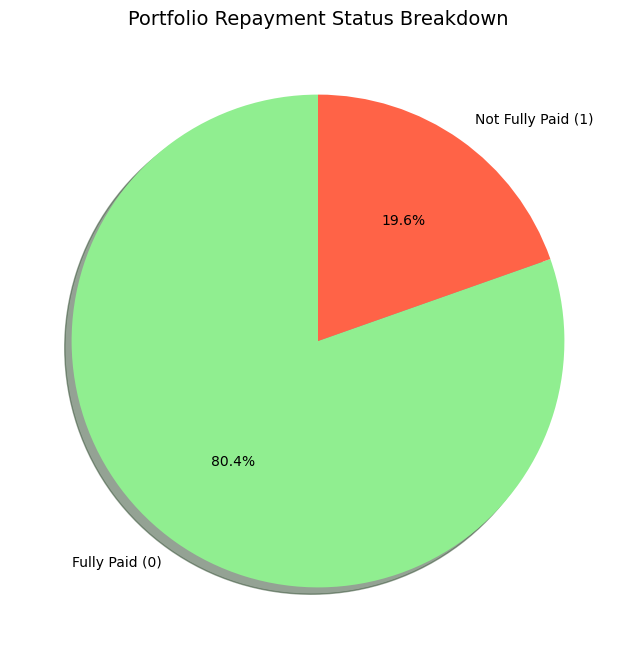

In [13]:
class IrisVisualizationProject:
    """
    Class for the Fisher Iris project data analysis.
    
    Attributes:
        iris_df (pd.DataFrame): Data containing sepal/petal measurements and species.
    """
    
    def __init__(self):
        # Load and convert the iris data into a dataframe
        iris_data = load_iris()
        self.iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
        self.iris_df['species'] = [iris_data.target_names[i] for i in iris_data.target]
        print("Iris dataset loaded")

    def plot_petal_comparison(self):
        # Scatter Plot Function: show species differentiation based on petals by colors
        plt.figure(figsize=(10, 6))
        colors = {'setosa': 'teal', 'versicolor': 'orange', 'virginica': 'purple'}
        
        for species in self.iris_df['species'].unique():
            subset = self.iris_df[self.iris_df['species'] == species]
            plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'], 
                        label=species, c=colors[species], edgecolors='k', alpha=0.7, s=80)
        
        plt.title('Iris Species Differences: Petal Length vs Petal Width', fontsize=14)
        plt.xlabel('Petal Length (cm)')
        plt.ylabel('Petal Width (cm)')
        plt.legend(title='Species')
        plt.grid(visible=True, which='both', linestyle='--', alpha=0.5)
        plt.savefig('iris_petal_scatter.png', dpi=300)
        plt.show()

    def plot_sepal_distribution(self):
        # Histogram Function: Shows frequency distribution of sepal width.
        plt.figure(figsize=(10, 6))
        for species in self.iris_df['species'].unique():
            data = self.iris_df[self.iris_df['species'] == species]['sepal width (cm)']
            plt.hist(data, bins=12, alpha=0.5, label=species, edgecolor='black')
        
        plt.title('Frequency Distribution of Sepal Width', fontsize=14)
        plt.xlabel('Sepal Width (cm)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.savefig('iris_sepal_hist.png', dpi=300)
        plt.show()

    def plot_trait_boxplot(self):
        # Box Plot Function: Visualizes the difference in sepal length across species.
        plt.figure(figsize=(10, 6))
        data_to_plot = [self.iris_df[self.iris_df['species'] == s]['sepal length (cm)'] 
                        for s in self.iris_df['species'].unique()]
        
        # Updated 'labels' to 'tick_labels' to avoid MatplotlibDeprecationWarning
        plt.boxplot(data_to_plot, tick_labels=self.iris_df['species'].unique(), patch_artist=True)
        plt.title('Sepal Length Variance by Species', fontsize=14)
        plt.ylabel('Sepal Length (cm)')
        plt.grid(visible=True, axis='y', alpha=0.3)
        plt.savefig('iris_sepal_box.png', dpi=300)
        plt.show()

class LoanDataAnalysis:
    """
    A class meant to perform exploratory visual analysis on loan lending datasets.
    """
    def __init__(self, file_path='loan_data.csv'):
        try:
            self.df = pd.read_csv(file_path)
            print("Loan dataset loaded")
        except FileNotFoundError:
            print("Error: loan_data.csv not found. Using Mock data mirroring Kaggle structure.")
            # Mock data generation for robustness
            np.random.seed(42)
            self.df = pd.DataFrame({
                'loan_amount': np.random.normal(12000, 4000, 500),
                'int_rate': np.random.uniform(0.06, 0.20, 500),
                'purpose': np.random.choice(['debt_consolidation', 'credit_card', 'home_improvement', 'educational'], 500),
                'not_fully_paid': np.random.choice([0, 1], 500, p=[0.8, 0.2])
            })

    def plot_loan_purpose(self):
        # Bar Plot: Categorizes loan applications and shows commonality.
        counts = self.df['purpose'].value_counts().sort_values()
        plt.figure(figsize=(10, 6))
        plt.bar(counts.index, counts.values, color='skyblue', edgecolor='navy')
        plt.title('Primary Reasons for Loan Applications', fontsize=14)
        plt.xlabel('Loan Purpose')
        plt.ylabel('Count of Applicants')
        plt.xticks(rotation=15)
        plt.savefig('loan_purpose_bar.png', dpi=300)
        plt.show()

    def plot_interest_distribution(self):
        # Histogram: Displays the distribution of interest rates.
        plt.figure(figsize=(10, 6))
        plt.hist(self.df['int_rate'], bins=15, color='salmon', edgecolor='black')
        plt.title('Distribution of Loan Interest Rates', fontsize=14)
        plt.xlabel('Interest Rate (%)')
        plt.ylabel('Frequency')
        plt.grid(visible=True, alpha=0.4)
        plt.savefig('loan_int_hist.png', dpi=300)
        plt.show()

    def plot_repayment_status(self):
        # Pie Chart: Shows ratio of fully paid vs defaulting loans.
        status = self.df['not_fully_paid'].value_counts()
        plt.figure(figsize=(8, 8))
        labels = ['Fully Paid (0)', 'Not Fully Paid (1)']
        plt.pie(status, labels=labels, autopct='%1.1f%%', 
                colors=['lightgreen', 'tomato'], shadow=True, startangle=90)
        plt.title('Portfolio Repayment Status Breakdown', fontsize=14)
        plt.savefig('loan_repayment_pie.png', dpi=300)
        plt.show()

# Code Execution control block
if __name__ == "__main__":
    # Part one: Iris Analysis
    iris_project = IrisVisualizationProject()
    iris_project.plot_petal_comparison()
    iris_project.plot_sepal_distribution()
    iris_project.plot_trait_boxplot()

    # Part two: Loan Data Analysis
    loan_project = LoanDataAnalysis('loan_data.csv') 
    loan_project.plot_loan_purpose()
    loan_project.plot_interest_distribution()
    loan_project.plot_repayment_status()